In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import random
import time
from ResNet import ResNet50
from EA_ResNet import EA_ResNet50

# ========== REPRODUCIBILITY ==========
SEED = 42

def set_seed(seed):
    """Set seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed set to {SEED}")

/media/tan/F/RESEARCH/env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/media/tan/F/RESEARCH/env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Random seed set to 42


In [2]:
from datasets import load_dataset
from torchvision import transforms
from PIL import Image

# ========== DATASET LOADING ==========
cache_dir = "/media/tan/F/RESEARCH/week2/mini-imagenet-cache"

# Load train, validation, test splits
train_ds = load_dataset("timm/mini-imagenet", split='train', cache_dir=cache_dir)
val_ds = load_dataset("timm/mini-imagenet", split='validation', cache_dir=cache_dir)
test_ds = load_dataset("timm/mini-imagenet", split='test', cache_dir=cache_dir)

print(f"Train dataset size: {len(train_ds)}")
print(f"Validation dataset size: {len(val_ds)}")
print(f"Test dataset size: {len(test_ds)}")
print(f"Columns: {train_ds.column_names}")

Train dataset size: 50000
Validation dataset size: 10000
Test dataset size: 5000
Columns: ['image', 'label']


In [3]:
# ========== DATA PREPROCESSING ==========

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

class MiniImageNetDataset(Dataset):
    """PyTorch Dataset wrapper for Hugging Face mini-ImageNet"""
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image']
        if image.mode != 'RGB':
            image = image.convert('RGB')
        label = item['label']
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Create dataset instances
train_dataset = MiniImageNetDataset(train_ds, transform=transform)
val_dataset = MiniImageNetDataset(val_ds, transform=transform)
test_dataset = MiniImageNetDataset(test_ds, transform=transform)

print(f"Dataset created. Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

Dataset created. Train size: 50000, Val size: 10000, Test size: 5000


In [4]:
# ========== DATA LOADERS ==========

BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"DataLoaders created. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

DataLoaders created. Train batches: 1563, Val batches: 313, Test batches: 157
Device: cuda


In [ ]:
# ========== WEIGHT INITIALIZATION ==========

def init_weights(m):
    """Initialize weights using Kaiming initialization"""
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def train_epoch(model, train_loader, criterion, optimizer, device, epoch=1):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch [{epoch}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}, Acc: {100*correct/total:.2f}%")
    
    avg_loss = total_loss / len(train_loader)
    avg_acc = 100 * correct / total
    return avg_loss, avg_acc

def validate(model, val_loader, criterion, device):
    """Validate model on validation set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(val_loader)
    avg_acc = 100 * correct / total
    return avg_loss, avg_acc

def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, device, 
                              num_epochs=20, patience=5, model_name="model"):
    """Train with early stopping based on validation loss"""
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    for epoch in range(1, num_epochs + 1):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, epoch)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"\nEpoch {epoch}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), f"{model_name}_best.pth")
            print(f"  ✓ Best model saved (Val Loss: {val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  ✗ No improvement ({patience_counter}/{patience})")
            
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch}!")
                # Load best model
                model.load_state_dict(torch.load(f"{model_name}_best.pth"))
                break
    
    return train_losses, train_accs, val_losses, val_accs

def evaluate(model, test_loader, device):
    """Evaluate model on test set"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

print("Training and evaluation functions defined (with Early Stopping)")


Training and evaluation functions defined


In [ ]:
# ========== TRAINING RESNET50 ==========
print("\n" + "="*70)
print("TRAINING RESNET50")
print("="*70)

# Reset seed before creating model for reproducibility
set_seed(SEED)

# Create and initialize model
resnet_model = ResNet50(num_classes=100)
resnet_model.apply(init_weights)
resnet_model = resnet_model.to(device)

# Setup training
learning_rate = 0.001
resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate)

# Train ResNet50 with Early Stopping
print(f"Training ResNet50 with LR={learning_rate}, BATCH_SIZE={BATCH_SIZE}")
resnet_start_time = time.time()
resnet_train_losses, resnet_train_accs, resnet_val_losses, resnet_val_accs = train_with_early_stopping(
    resnet_model, train_loader, val_loader, resnet_criterion, resnet_optimizer, device,
    num_epochs=20, patience=5, model_name="resnet50"
)
resnet_train_time = time.time() - resnet_start_time

print(f"\nResNet50 - Training complete!")
print(f"  Total Training Time: {resnet_train_time:.2f} seconds")
print(f"  Final Training Loss: {resnet_train_losses[-1]:.4f}")
print(f"  Final Training Accuracy: {resnet_train_accs[-1]:.2f}%")
print(f"  Final Validation Loss: {resnet_val_losses[-1]:.4f}")
print(f"  Final Validation Accuracy: {resnet_val_accs[-1]:.2f}%")

# Evaluate on test set
resnet_test_acc = evaluate(resnet_model, test_loader, device)
print(f"  Test Accuracy: {resnet_test_acc:.2f}%")



TRAINING RESNET50
Training ResNet50 with LR=0.001, BATCH_SIZE=32
Epoch [1], Batch [10/1563], Loss: 6.1736, Acc: 1.88%
Epoch [1], Batch [20/1563], Loss: 4.9079, Acc: 1.72%
Epoch [1], Batch [30/1563], Loss: 4.7939, Acc: 1.25%
Epoch [1], Batch [40/1563], Loss: 4.8158, Acc: 1.33%
Epoch [1], Batch [50/1563], Loss: 4.7258, Acc: 1.31%
Epoch [1], Batch [60/1563], Loss: 4.6764, Acc: 1.30%
Epoch [1], Batch [70/1563], Loss: 4.4105, Acc: 1.43%
Epoch [1], Batch [80/1563], Loss: 4.7203, Acc: 1.60%
Epoch [1], Batch [90/1563], Loss: 4.6503, Acc: 1.60%
Epoch [1], Batch [100/1563], Loss: 4.7632, Acc: 1.53%
Epoch [1], Batch [110/1563], Loss: 4.5672, Acc: 1.56%
Epoch [1], Batch [120/1563], Loss: 4.5512, Acc: 1.61%
Epoch [1], Batch [130/1563], Loss: 4.5909, Acc: 1.61%
Epoch [1], Batch [140/1563], Loss: 4.5968, Acc: 1.63%
Epoch [1], Batch [150/1563], Loss: 4.4402, Acc: 1.67%
Epoch [1], Batch [160/1563], Loss: 4.4830, Acc: 1.70%
Epoch [1], Batch [170/1563], Loss: 4.4707, Acc: 1.69%
Epoch [1], Batch [180/156

In [ ]:
# ========== TRAINING EA_RESNET50 ==========
print("\n" + "="*70)
print("TRAINING EA_RESNET50 (with Efficient Attention)")
print("="*70)

# Reset seed before creating model for fair comparison
set_seed(SEED)

# Create and initialize model
ea_model = EA_ResNet50(num_classes=100)
ea_model.apply(init_weights)
ea_model = ea_model.to(device)

# Setup training (same parameters as ResNet50)
ea_criterion = nn.CrossEntropyLoss()
ea_optimizer = optim.Adam(ea_model.parameters(), lr=learning_rate)

# Train EA_ResNet50 with Early Stopping
print(f"Training EA_ResNet50 with LR={learning_rate}, BATCH_SIZE={BATCH_SIZE}")
ea_start_time = time.time()
ea_train_losses, ea_train_accs, ea_val_losses, ea_val_accs = train_with_early_stopping(
    ea_model, train_loader, val_loader, ea_criterion, ea_optimizer, device,
    num_epochs=20, patience=5, model_name="ea_resnet50"
)
ea_train_time = time.time() - ea_start_time

print(f"\nEA_ResNet50 - Training complete!")
print(f"  Total Training Time: {ea_train_time:.2f} seconds")
print(f"  Final Training Loss: {ea_train_losses[-1]:.4f}")
print(f"  Final Training Accuracy: {ea_train_accs[-1]:.2f}%")
print(f"  Final Validation Loss: {ea_val_losses[-1]:.4f}")
print(f"  Final Validation Accuracy: {ea_val_accs[-1]:.2f}%")

# Evaluate on test set
ea_test_acc = evaluate(ea_model, test_loader, device)
print(f"  Test Accuracy: {ea_test_acc:.2f}%")



TRAINING EA_RESNET50 (with Efficient Attention)
Training EA_ResNet50 with LR=0.001, BATCH_SIZE=32
Epoch [1], Batch [10/1563], Loss: 6.5463, Acc: 1.56%
Epoch [1], Batch [20/1563], Loss: 5.0125, Acc: 0.94%
Epoch [1], Batch [30/1563], Loss: 4.9935, Acc: 1.15%
Epoch [1], Batch [40/1563], Loss: 5.0116, Acc: 1.02%
Epoch [1], Batch [50/1563], Loss: 4.9699, Acc: 1.00%
Epoch [1], Batch [60/1563], Loss: 4.7992, Acc: 0.99%
Epoch [1], Batch [70/1563], Loss: 4.6900, Acc: 1.25%
Epoch [1], Batch [80/1563], Loss: 4.6296, Acc: 1.25%
Epoch [1], Batch [90/1563], Loss: 4.6584, Acc: 1.22%
Epoch [1], Batch [100/1563], Loss: 4.6316, Acc: 1.19%
Epoch [1], Batch [110/1563], Loss: 4.6133, Acc: 1.08%
Epoch [1], Batch [120/1563], Loss: 4.5316, Acc: 1.12%
Epoch [1], Batch [130/1563], Loss: 4.5748, Acc: 1.06%
Epoch [1], Batch [140/1563], Loss: 4.6461, Acc: 1.03%
Epoch [1], Batch [150/1563], Loss: 4.6526, Acc: 1.06%
Epoch [1], Batch [160/1563], Loss: 4.5880, Acc: 1.09%
Epoch [1], Batch [170/1563], Loss: 4.6596, Acc

In [ ]:
# ========== COMPARISON RESULTS ==========
print("\n" + "="*70)
print("COMPARISON: ResNet50 vs EA_ResNet50")
print("="*70)

# Use best validation metrics instead of training metrics
resnet_best_val_idx = resnet_val_losses.index(min(resnet_val_losses))
ea_best_val_idx = ea_val_losses.index(min(ea_val_losses))

resnet_final_train_loss = resnet_train_losses[resnet_best_val_idx]
resnet_final_train_acc = resnet_train_accs[resnet_best_val_idx]
ea_final_train_loss = ea_train_losses[ea_best_val_idx]
ea_final_train_acc = ea_train_accs[ea_best_val_idx]

print(f"\n{'Metric':<30} {'ResNet50':<20} {'EA_ResNet50':<20} {'Difference':<15}")
print("-" * 85)

# Training Time
time_diff = ea_train_time - resnet_train_time
time_diff_pct = (time_diff / resnet_train_time) * 100 if resnet_train_time > 0 else 0
print(f"{'Training Time (sec)':<30} {resnet_train_time:<20.2f} {ea_train_time:<20.2f} {time_diff_pct:>+.1f}%")

# Validation Loss (Best)
val_loss_diff = ea_val_losses[ea_best_val_idx] - resnet_val_losses[resnet_best_val_idx]
print(f"{'Best Validation Loss':<30} {resnet_val_losses[resnet_best_val_idx]:<20.4f} {ea_val_losses[ea_best_val_idx]:<20.4f} {val_loss_diff:>+.4f}")

# Validation Accuracy (Best)
val_acc_diff = ea_val_accs[ea_best_val_idx] - resnet_val_accs[resnet_best_val_idx]
print(f"{'Best Validation Accuracy (%)':<30} {resnet_val_accs[resnet_best_val_idx]:<20.2f} {ea_val_accs[ea_best_val_idx]:<20.2f} {val_acc_diff:>+.2f}")

# Test Accuracy (Main Metric)
test_acc_diff = ea_test_acc - resnet_test_acc
print(f"{'Test Accuracy (%)':<30} {resnet_test_acc:<20.2f} {ea_test_acc:<20.2f} {test_acc_diff:>+.2f}")

print("-" * 85)

# Summary
print(f"\n{'SUMMARY':-^70}")
if ea_test_acc > resnet_test_acc:
    print(f"✓ EA_ResNet50 achieves HIGHER test accuracy by {test_acc_diff:.2f}%")
elif ea_test_acc < resnet_test_acc:
    print(f"✗ EA_ResNet50 achieves LOWER test accuracy by {abs(test_acc_diff):.2f}%")
else:
    print(f"= Both models achieve similar test accuracy")

if ea_val_accs[ea_best_val_idx] > resnet_val_accs[resnet_best_val_idx]:
    print(f"✓ EA_ResNet50 achieves BETTER validation accuracy by {val_acc_diff:.2f}%")
elif ea_val_accs[ea_best_val_idx] < resnet_val_accs[resnet_best_val_idx]:
    print(f"✗ EA_ResNet50 achieves WORSE validation accuracy by {abs(val_acc_diff):.2f}%")

if ea_train_time < resnet_train_time:
    print(f"✓ EA_ResNet50 trains FASTER by {abs(time_diff):.2f}s ({abs(time_diff_pct):.1f}% faster)")
elif ea_train_time > resnet_train_time:
    print(f"✗ EA_ResNet50 trains SLOWER by {time_diff:.2f}s ({time_diff_pct:.1f}% slower)")

print("-" * 70)



COMPARISON: ResNet50 vs EA_ResNet50

Metric                         ResNet50             EA_ResNet50          Difference     
-------------------------------------------------------------------------------------
Training Time (sec)            339.28               400.76               +18.1%
Training Loss                  4.1674               4.6471               +0.4798
Training Accuracy (%)          6.96                 0.98                 -5.98
Test Accuracy (%)              12.94                1.02                 -11.92
-------------------------------------------------------------------------------------

-------------------------------SUMMARY--------------------------------
✗ EA_ResNet50 achieves LOWER test accuracy by 11.92%
✗ EA_ResNet50 trains SLOWER by 61.48s (18.1% slower)
----------------------------------------------------------------------


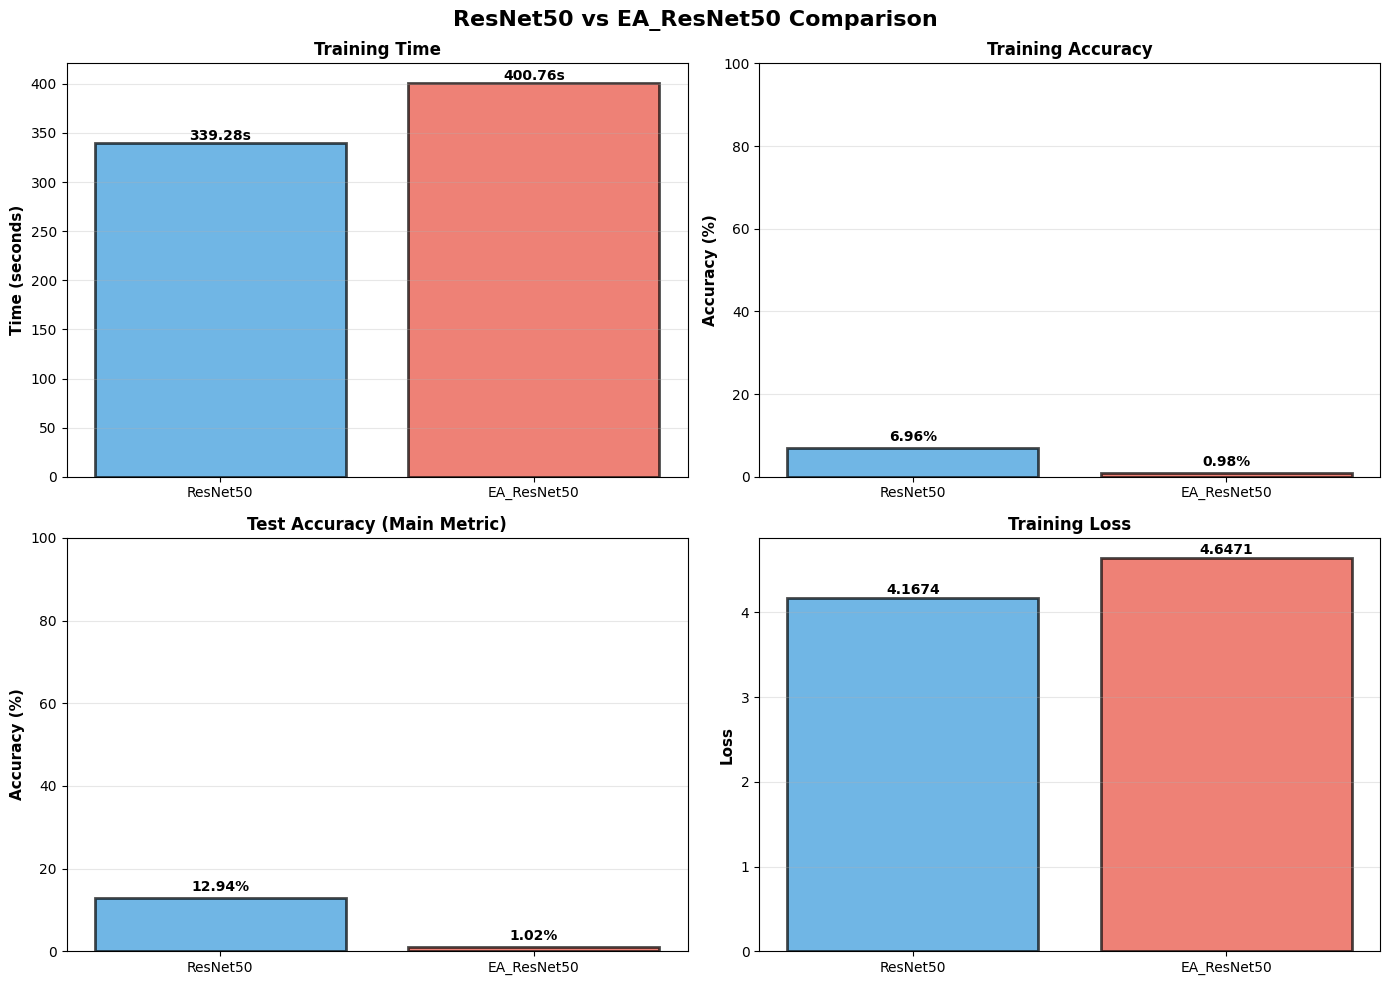

Comparison charts saved to: /media/tan/F/RESEARCH/week2/comparison_charts.png


In [ ]:
# ========== VISUALIZATION ==========
import matplotlib.pyplot as plt
import numpy as np

# Create comprehensive comparison figure
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

fig.suptitle('ResNet50 vs EA_ResNet50 Comprehensive Comparison', fontsize=18, fontweight='bold')

models = ['ResNet50', 'EA_ResNet50']
colors = ['#3498db', '#e74c3c']

# ===== ROW 1: Training Curves =====
# Training Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(resnet_train_losses, label='ResNet50', color=colors[0], marker='o', linewidth=2)
ax1.plot(ea_train_losses, label='EA_ResNet50', color=colors[1], marker='s', linewidth=2)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss', fontweight='bold')
ax1.set_title('Training Loss', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Validation Loss
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(resnet_val_losses, label='ResNet50', color=colors[0], marker='o', linewidth=2)
ax2.plot(ea_val_losses, label='EA_ResNet50', color=colors[1], marker='s', linewidth=2)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Loss', fontweight='bold')
ax2.set_title('Validation Loss (Early Stopping Point)', fontweight='bold')
ax2.axvline(x=resnet_best_val_idx, color=colors[0], linestyle='--', alpha=0.7)
ax2.axvline(x=ea_best_val_idx, color=colors[1], linestyle='--', alpha=0.7)
ax2.legend()
ax2.grid(alpha=0.3)

# Training Accuracy
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(resnet_train_accs, label='ResNet50', color=colors[0], marker='o', linewidth=2)
ax3.plot(ea_train_accs, label='EA_ResNet50', color=colors[1], marker='s', linewidth=2)
ax3.set_xlabel('Epoch', fontweight='bold')
ax3.set_ylabel('Accuracy (%)', fontweight='bold')
ax3.set_title('Training Accuracy', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# ===== ROW 2: Final Metrics =====
# Validation Accuracy
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(resnet_val_accs, label='ResNet50', color=colors[0], marker='o', linewidth=2)
ax4.plot(ea_val_accs, label='EA_ResNet50', color=colors[1], marker='s', linewidth=2)
ax4.set_xlabel('Epoch', fontweight='bold')
ax4.set_ylabel('Accuracy (%)', fontweight='bold')
ax4.set_title('Validation Accuracy', fontweight='bold')
ax4.axvline(x=resnet_best_val_idx, color=colors[0], linestyle='--', alpha=0.7)
ax4.axvline(x=ea_best_val_idx, color=colors[1], linestyle='--', alpha=0.7)
ax4.legend()
ax4.grid(alpha=0.3)

# Best Validation Accuracy Comparison
ax5 = fig.add_subplot(gs[1, 1])
best_val_accs = [resnet_val_accs[resnet_best_val_idx], ea_val_accs[ea_best_val_idx]]
bars5 = ax5.bar(models, best_val_accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax5.set_ylabel('Accuracy (%)', fontweight='bold')
ax5.set_title('Best Validation Accuracy', fontweight='bold')
ax5.set_ylim([0, 100])
ax5.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars5, best_val_accs):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# Test Accuracy
ax6 = fig.add_subplot(gs[1, 2])
test_accs = [resnet_test_acc, ea_test_acc]
bars6 = ax6.bar(models, test_accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax6.set_ylabel('Accuracy (%)', fontweight='bold')
ax6.set_title('Test Accuracy (Final)', fontweight='bold')
ax6.set_ylim([0, 100])
ax6.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars6, test_accs):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# ===== ROW 3: Summary Metrics =====
# Training Time
ax7 = fig.add_subplot(gs[2, 0])
times = [resnet_train_time, ea_train_time]
bars7 = ax7.bar(models, times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax7.set_ylabel('Time (seconds)', fontweight='bold')
ax7.set_title('Total Training Time', fontweight='bold')
ax7.grid(axis='y', alpha=0.3)
for bar, time in zip(bars7, times):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{time:.1f}s', ha='center', va='bottom', fontweight='bold')

# Epochs Trained
ax8 = fig.add_subplot(gs[2, 1])
epochs_trained = [resnet_best_val_idx + 1, ea_best_val_idx + 1]
bars8 = ax8.bar(models, epochs_trained, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax8.set_ylabel('Epochs', fontweight='bold')
ax8.set_title('Epochs Trained (Early Stopped)', fontweight='bold')
ax8.grid(axis='y', alpha=0.3)
for bar, ep in zip(bars8, epochs_trained):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f'{int(ep)}', ha='center', va='bottom', fontweight='bold')

# Best Val Loss
ax9 = fig.add_subplot(gs[2, 2])
best_val_losses = [resnet_val_losses[resnet_best_val_idx], ea_val_losses[ea_best_val_idx]]
bars9 = ax9.bar(models, best_val_losses, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax9.set_ylabel('Loss', fontweight='bold')
ax9.set_title('Best Validation Loss', fontweight='bold')
ax9.grid(axis='y', alpha=0.3)
for bar, loss in zip(bars9, best_val_losses):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{loss:.4f}', ha='center', va='bottom', fontweight='bold')

plt.savefig('/media/tan/F/RESEARCH/week2/comparison_charts_with_early_stopping.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comprehensive comparison charts saved to: /media/tan/F/RESEARCH/week2/comparison_charts_with_early_stopping.png")
